In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import numpy as np
from textwrap import wrap
import seaborn as sns

In [28]:
sns.set_style("white")
sns.set_context("notebook")
sns.set_palette("husl")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

In [30]:
mapping = {
    "Universalización y Plenitud de Derechos": [
        "Libertad",
        "Igualdad en el derecho al voto",
        "Derechos humanos",
        "Tolerancia",
    ],
    "Participación Ciudadana Amplia y Sostenida": [
        "Control ciudadano de los asuntos público-políticos",
        "Búsqueda no violenta del poder",
        "Pluralidad",
        "Interés colectivo",
    ],
    "Deliberación Pública y Racional": [
        "Racionalidad",
        "Paz social",
    ],
    "Rendición de Cuentas y Transparencia": [
        "Control y limitación del abuso de poder",
        "Legitimidad de los representantes",
        "Respaldo a las reglas de la democracia representativa",
    ],
    "Igualdad Sustantiva y Reducción de Desigualdades": [
        "Igualdad de oportunidades en la toma de decisiones",
        "Respeto a la soberanía de los Estados",
        "Mercado",
    ]
}

def create_academic_treegraph():
    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    
    # Colores académicos profesionales
    colors = ['#2E4057', '#048A81', '#54C6EB', '#F18F01', '#C73E1D']
    light_colors = ['#E8EEF5', '#E0F2F1', '#E1F5FE', '#FFF3E0', '#FFEBEE']
    
    # Título principal
    nodo_central = "DIMENSIONES DE LA DEMOCRACIA"
    
    # Posiciones para el layout
    center_x, center_y = 8, 6
    radius = 4.5
    
    # Dibujar nodo central
    central_box = FancyBboxPatch(
        (center_x - 2.5, center_y - 0.8), 5, 1.6,
        boxstyle="round,pad=0.1",
        facecolor='#34495E',
        edgecolor='#2C3E50',
        linewidth=2
    )
    ax.add_patch(central_box)
    
    ax.text(center_x, center_y, nodo_central, 
            ha='center', va='center', fontsize=14, fontweight='bold',
            color='white', wrap=True)
    
    # Calcular posiciones para cada grupo principal
    num_groups = len(mapping)
    angles = np.linspace(0, 2*np.pi, num_groups, endpoint=False)
    
    for i, (group_name, variables) in enumerate(mapping.items()):
        # Posición del nodo grupo
        group_x = center_x + radius * np.cos(angles[i])
        group_y = center_y + radius * np.sin(angles[i])
        
        # Ajuste de tamaño según longitud del texto
        box_width = max(3, len(group_name) * 0.08)
        box_height = 1.2
        
        # Dibujar nodo grupo principal
        group_box = FancyBboxPatch(
            (group_x - box_width/2, group_y - box_height/2), 
            box_width, box_height,
            boxstyle="round,pad=0.1",
            facecolor=colors[i],
            edgecolor='#2C3E50',
            linewidth=1.5,
            alpha=0.9
        )
        ax.add_patch(group_box)
        
        # Texto del grupo con ajuste de líneas
        wrapped_text = '\n'.join(wrap(group_name, width=20))
        ax.text(group_x, group_y, wrapped_text, 
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white')
        
        # Línea conectora desde centro
        ax.plot([center_x, group_x], [center_y, group_y], 
                color='#34495E', linewidth=2, alpha=0.7)
        
        # Posiciones para variables individuales
        var_radius = 2.8
        num_vars = len(variables)
        
        if num_vars == 1:
            var_angles = [0]
        else:
            # Distribuir variables alrededor del grupo
            start_angle = angles[i] - np.pi/4
            end_angle = angles[i] + np.pi/4
            var_angles = np.linspace(start_angle, end_angle, num_vars)
        
        for j, variable in enumerate(variables):
            # Posición de cada variable
            var_x = group_x + var_radius * np.cos(var_angles[j])
            var_y = group_y + var_radius * np.sin(var_angles[j])
            
            # Tamaño dinámico para variables
            var_box_width = max(2, len(variable) * 0.06)
            var_box_height = 0.8
            
            # Dibujar nodo variable
            var_box = FancyBboxPatch(
                (var_x - var_box_width/2, var_y - var_box_height/2), 
                var_box_width, var_box_height,
                boxstyle="round,pad=0.05",
                facecolor=light_colors[i],
                edgecolor=colors[i],
                linewidth=1,
                alpha=0.8
            )
            ax.add_patch(var_box)
            
            # Texto de la variable
            wrapped_var_text = '\n'.join(wrap(variable, width=15))
            ax.text(var_x, var_y, wrapped_var_text, 
                    ha='center', va='center', fontsize=8,
                    color=colors[i], fontweight='normal')
            
            # Línea conectora desde grupo a variable
            ax.plot([group_x, var_x], [group_y, var_y], 
                    color=colors[i], linewidth=1.5, alpha=0.6)
    
    # Configuración de ejes y diseño
    ax.set_xlim(-1, 17)
    ax.set_ylim(-1, 13)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Título del gráfico
    plt.suptitle('Estructura Jerárquica de Variables Democráticas', 
                 fontsize=16, fontweight='bold', y=0.95, color='#2C3E50')
    
    # Subtítulo
    plt.figtext(0.5, 0.92, 'Análisis de Dimensiones y Componentes de la Democracia', 
                ha='center', fontsize=12, style='italic', color='#7F8C8D')
    
    # Leyenda de colores
    legend_elements = []
    for i, group_name in enumerate(mapping.keys()):
        legend_elements.append(patches.Patch(color=colors[i], 
                                           label=f'Dimensión {i+1}'))
    
    ax.legend(handles=legend_elements, loc='upper right', 
              bbox_to_anchor=(0.98, 0.98), fontsize=9,
              title='Dimensiones', title_fontsize=10)
    
    # Nota metodológica
    plt.figtext(0.02, 0.02, 
                'Fuente: Elaboración propia basada en variables democráticas identificadas\n'
                'Nota: El gráfico muestra la estructura jerárquica de 5 dimensiones principales '
                'y sus 16 variables constitutivas',
                fontsize=8, style='italic', color='#7F8C8D')
    
    plt.tight_layout()
    
    plt.show()


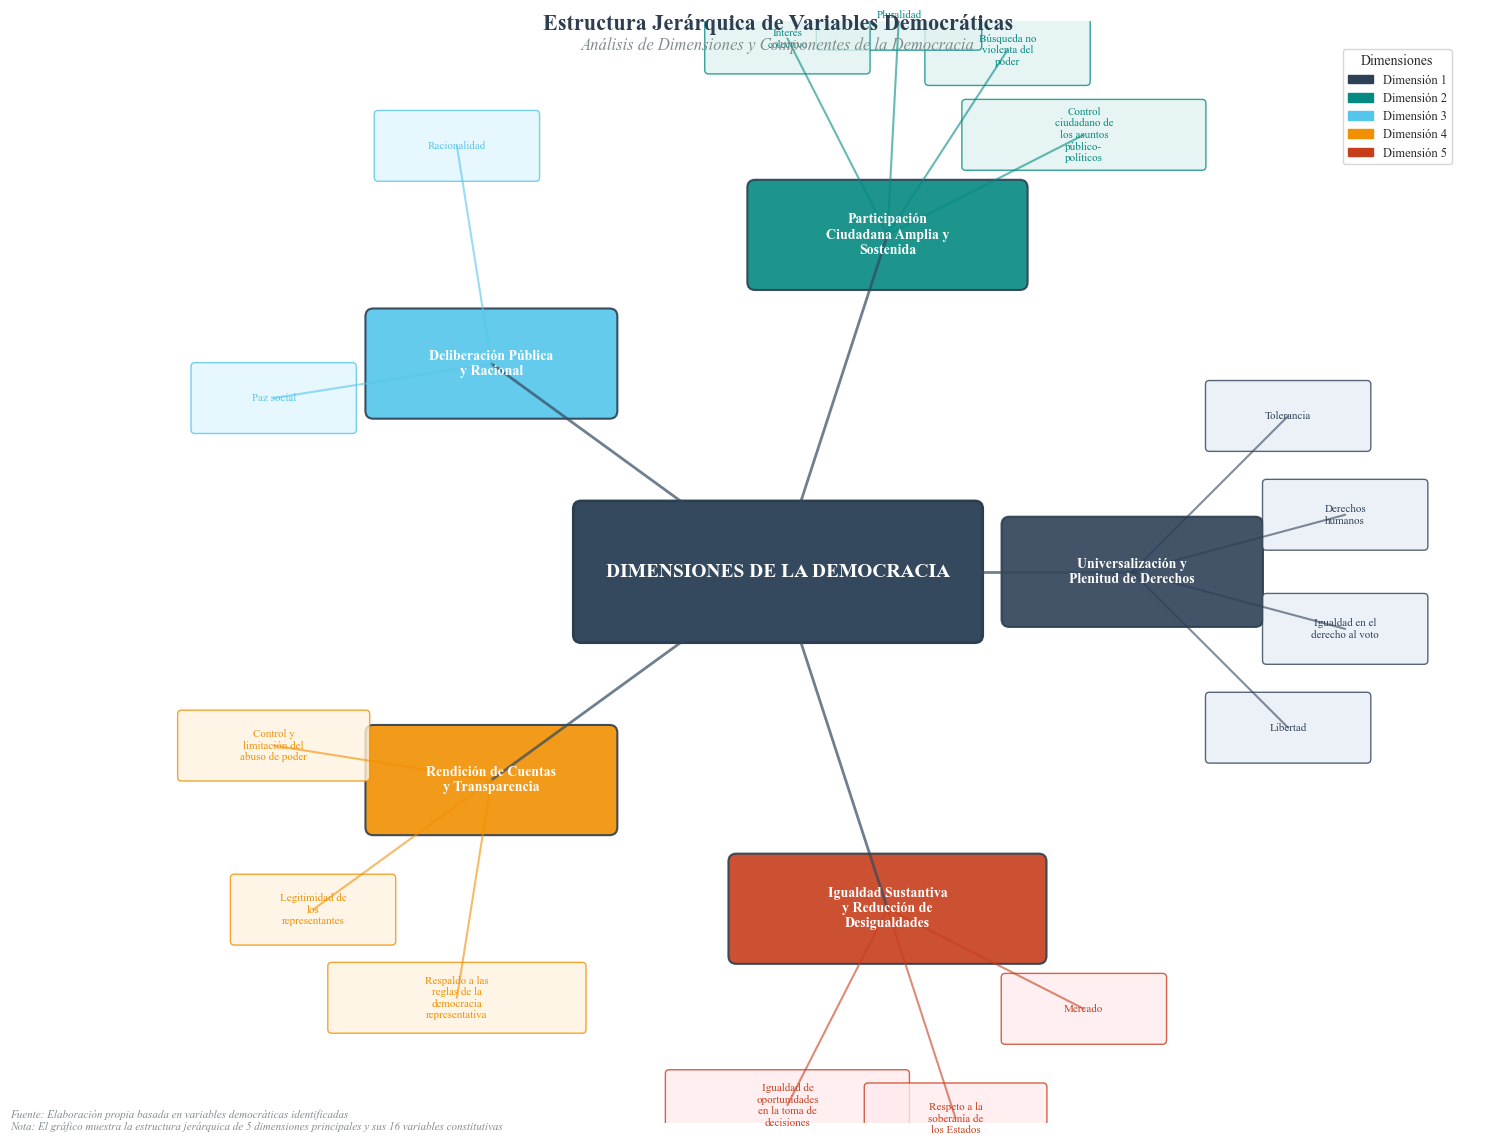

In [32]:
create_academic_treegraph()

In [33]:
def create_networkx_treegraph():
    try:
        import networkx as nx
    except ImportError:
        print("NetworkX no está instalado. Instalando...")
        import subprocess
        subprocess.check_call(["pip", "install", "networkx"])
        import networkx as nx
    
    # Crear grafo dirigido
    G = nx.DiGraph()
    
    # Agregar nodo central
    G.add_node("DEMOCRACIA", node_type="central")
    
    # Agregar nodos y conexiones
    for group_name, variables in mapping.items():
        G.add_node(group_name, node_type="dimension")
        G.add_edge("DEMOCRACIA", group_name)
        
        for variable in variables:
            G.add_node(variable, node_type="variable")
            G.add_edge(group_name, variable)
    
    # Crear visualización
    fig, ax = plt.subplots(1, 1, figsize=(18, 14))
    
    # Layout jerárquico
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
    
    # Separar nodos por tipo
    central_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'central']
    dimension_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'dimension']
    variable_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'variable']
    
    # Dibujar conexiones
    nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=1.5, alpha=0.7)
    
    # Dibujar nodos por tipo
    nx.draw_networkx_nodes(G, pos, nodelist=central_nodes, 
                          node_color='#2C3E50', node_size=3000, alpha=0.9)
    
    nx.draw_networkx_nodes(G, pos, nodelist=dimension_nodes, 
                          node_color='#3498DB', node_size=2000, alpha=0.8)
    
    nx.draw_networkx_nodes(G, pos, nodelist=variable_nodes, 
                          node_color='#ECF0F1', node_size=1200, alpha=0.9)
    
    # Etiquetas con formato académico
    labels = {}
    for node in G.nodes():
        if len(node) > 25:
            labels[node] = '\n'.join(wrap(node, width=15))
        else:
            labels[node] = node
    
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='normal')
    
    ax.set_title('Red de Variables Democráticas - Análisis Estructural', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.axis('off')
    plt.tight_layout()
    
    
    plt.show()


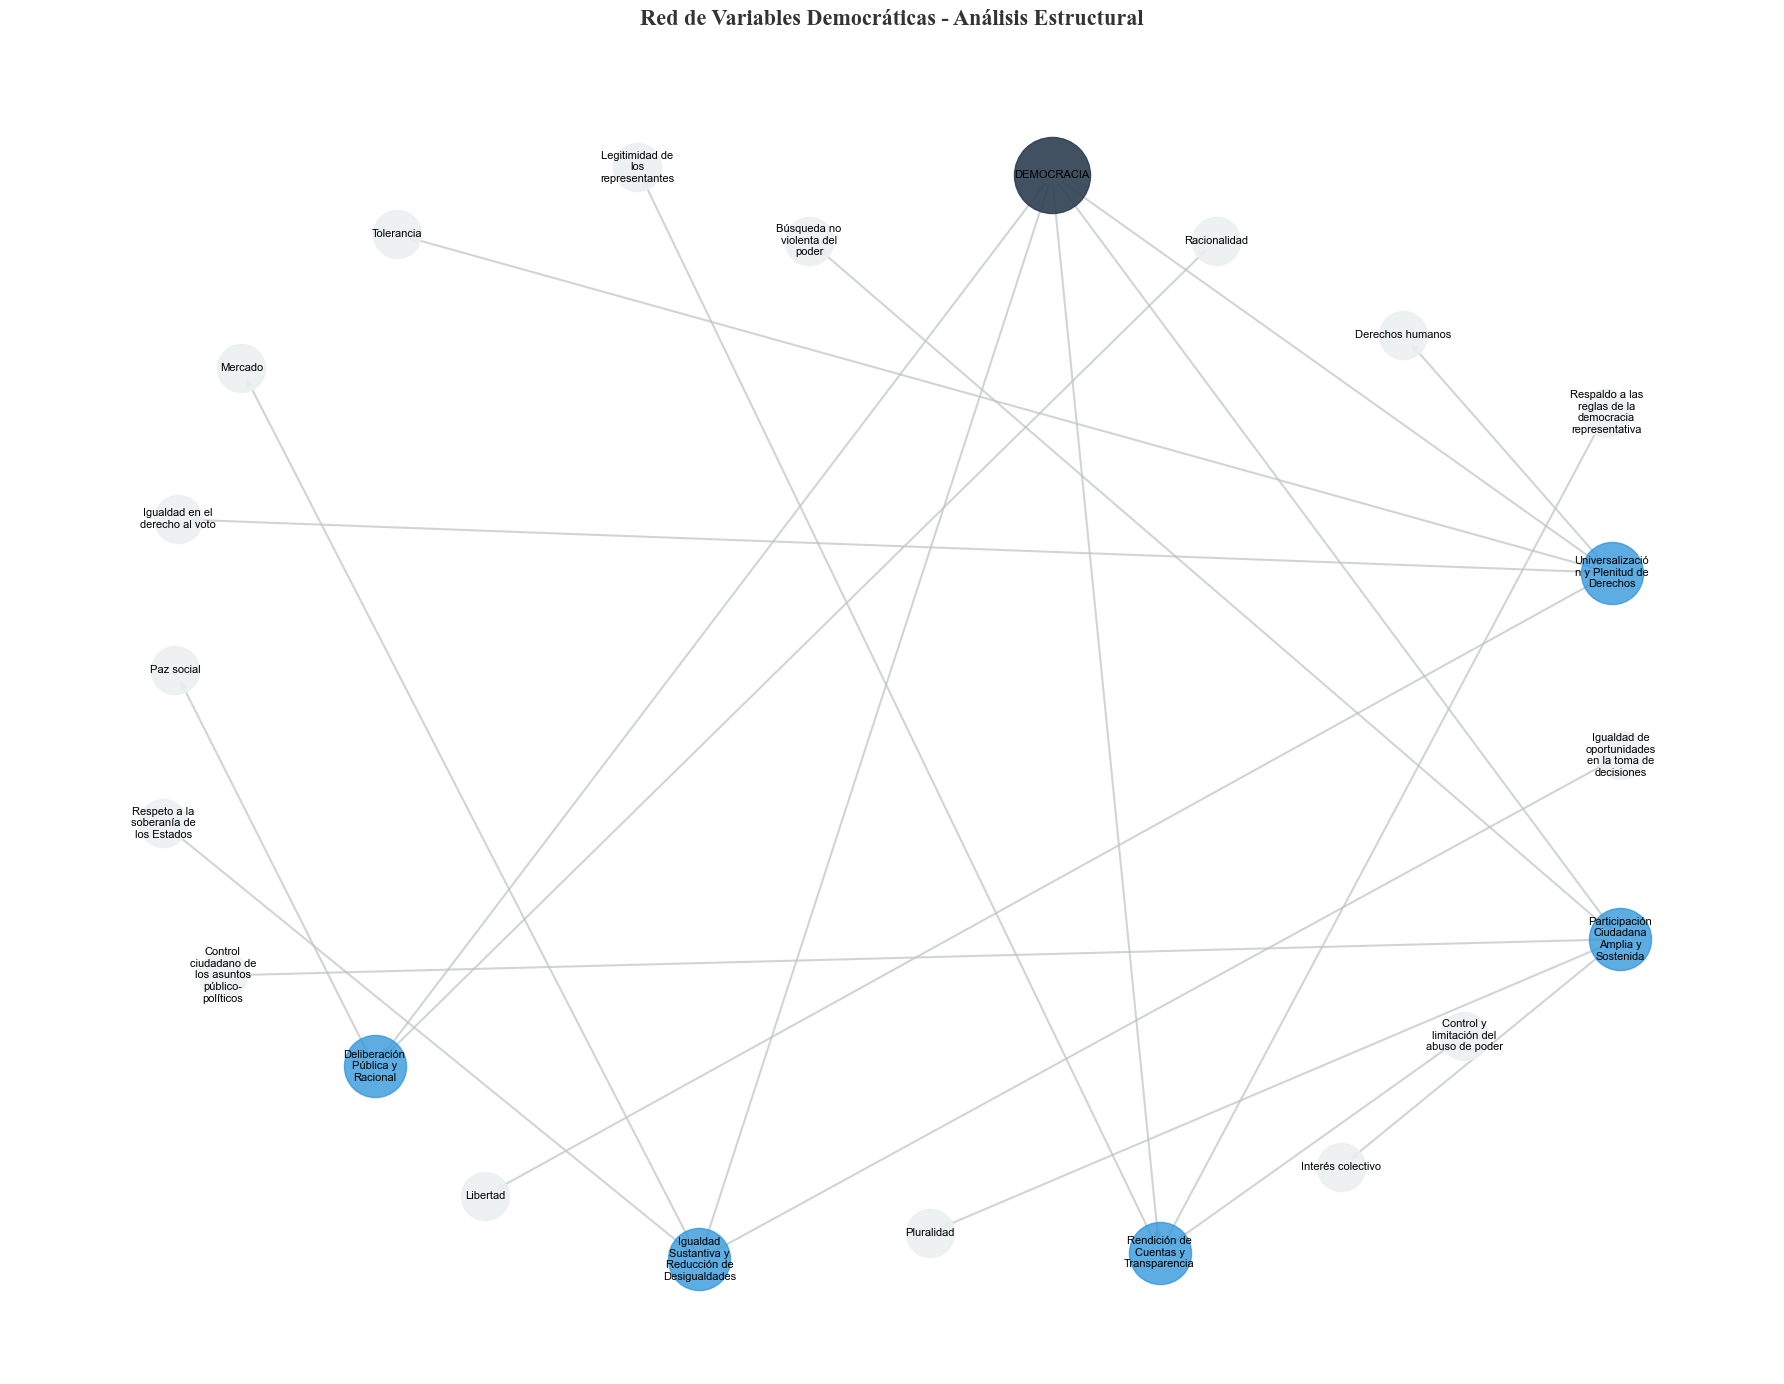

In [34]:
create_networkx_treegraph()